# Homework 2: VAR Forecasting with Economic Policy Uncertainty
## Forecasting and Nowcasting with Text as Data
### Barcelona School of Economics — DSDM Program, 2025/26

---

**Team Members:** Tizian Schenk · Èric Gutiérrez

**Submission Date:** June 19, 2026

**Instructor:** Álvaro Fernández-Gallardo (Banco de España / BSE)

---

## Overview

This notebook implements a structural Vector Autoregression (VAR) analysis
of the US economy using the Baker, Bloom & Davis (2016) Economic Policy
Uncertainty (EPU) index as a text-based macroeconomic indicator.

> All markdown cells, including the text, analyses, and interpretations, were removed from this notebook and incorporated into the report **`forecasting-h2_schenk_gutierrez.pdf`**.

---

In [1]:
# Imports and Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from fredapi import Fred
from dotenv import load_dotenv
import warnings
import os
import random
import statsmodels
from statsmodels.tsa.vector_ar.var_model import VAR
from scipy.linalg import cholesky

warnings.filterwarnings('ignore')

load_dotenv(dotenv_path="../.env")

FRED_API_KEY = os.environ.get("FRED_API_KEY")

if not FRED_API_KEY:
    raise ValueError(
        "FRED_API_KEY not found. "
        "Copy .env.example to .env and fill in your key."
    )

fred = Fred(api_key=FRED_API_KEY)

# Output folders
os.makedirs("../output", exist_ok=True)
os.makedirs("../data", exist_ok=True)

# Reproducibility
SEED = 20269999
np.random.seed(SEED)
random.seed(SEED)

## Part I
---

#### 1) DATASET CONSTRUCTION

In [2]:
# Download FRED data

# Date range
START = "1985-01-01"
END   = "2023-03-01"

# Download each series
# PAYEMS: nonfarm payroll employment (thousands of persons)
payems = fred.get_series("PAYEMS", observation_start=START, observation_end=END)

# PCEPI: personal consumption expenditures price index (index 2017=100)
pcepi  = fred.get_series("PCEPI",  observation_start=START, observation_end=END)

# INDPRO: industrial production index (index 2017=100)
indpro = fred.get_series("INDPRO", observation_start=START, observation_end=END)

# Combine into a single DataFrame with clean column names
fred_data = pd.DataFrame({
    "PAYEMS": payems,
    "PCEPI":  pcepi,
    "INDPRO": indpro,
})

fred_data.index.name = "date"

print(f"Shape: {fred_data.shape}")
print(f"\nFirst 3 rows:\n{fred_data.head(3)}")
print(f"\nLast 3 rows:\n{fred_data.tail(3)}")
print(f"\nAny missing values: {fred_data.isna().sum().sum()}")

Shape: (459, 3)

First 3 rows:
             PAYEMS   PCEPI   INDPRO
date                                
1985-01-01  96372.0  49.326  54.6322
1985-02-01  96503.0  49.555  54.7825
1985-03-01  96842.0  49.749  54.8653

Last 3 rows:
              PAYEMS    PCEPI    INDPRO
date                                   
2023-01-01  154776.0  119.018  100.5050
2023-02-01  155066.0  119.369  100.6416
2023-03-01  155134.0  119.538  101.0205

Any missing values: 0


In [3]:
# Load EPU index
# Downloaded from: https://www.policyuncertainty.com/us_monthly.html 

epu_raw = pd.read_excel(
    "../data/US_Policy_Uncertainty_Data.xlsx",
    sheet_name=0,
)

print("EPU raw columns:", epu_raw.columns.tolist())
print(epu_raw.head(5))

EPU raw columns: ['Year', 'Month', 'News_Based_Policy_Uncert_Index']
   Year  Month  News_Based_Policy_Uncert_Index
0  2026    5.0                      296.079533
1  2026    4.0                      297.404522
2  2026    3.0                      374.656546
3  2026    2.0                      374.191792
4  2026    1.0                      371.334964


In [4]:
# Data Cleaning and Merging

epu_clean = epu_raw.copy()
epu_clean = epu_clean.dropna(subset=["Month"]) # drop rows where Month is NaN

epu_clean["date"] = pd.to_datetime(
    epu_clean["Year"].astype(int).astype(str) + "-" +
    epu_clean["Month"].astype(int).astype(str) + "-01")

epu_clean = epu_clean.set_index("date")

epu_clean = epu_clean[["News_Based_Policy_Uncert_Index"]]

epu_clean = epu_clean.rename(
    columns={"News_Based_Policy_Uncert_Index": "EPU"}
)

epu_clean = epu_clean.sort_index()

# filter to period of interest: 1985M1 to 2023M3
epu_clean = epu_clean.loc["1985-01-01":"2023-03-01"]

print(f"EPU shape after filtering: {epu_clean.shape}")
print(f"\nFirst 3 rows:\n{epu_clean.head(3)}")
print(f"\nLast 3 rows:\n{epu_clean.tail(3)}")

data_levels = fred_data.join(epu_clean, how="inner")

print(f"\nMerged shape: {data_levels.shape}")
print(f"\nColumns: {data_levels.columns.tolist()}")
print(f"\nAny missing values: {data_levels.isna().sum().sum()}")
print(f"\nDate range: {data_levels.index[0]} → {data_levels.index[-1]}")

EPU shape after filtering: (459, 1)

First 3 rows:
                   EPU
date                  
1985-01-01  103.748803
1985-02-01   78.313193
1985-03-01  100.761475

Last 3 rows:
                   EPU
date                  
2023-01-01  161.427114
2023-02-01  152.967281
2023-03-01  200.489936

Merged shape: (459, 4)

Columns: ['PAYEMS', 'PCEPI', 'INDPRO', 'EPU']

Any missing values: 0

Date range: 1985-01-01 00:00:00 → 2023-03-01 00:00:00


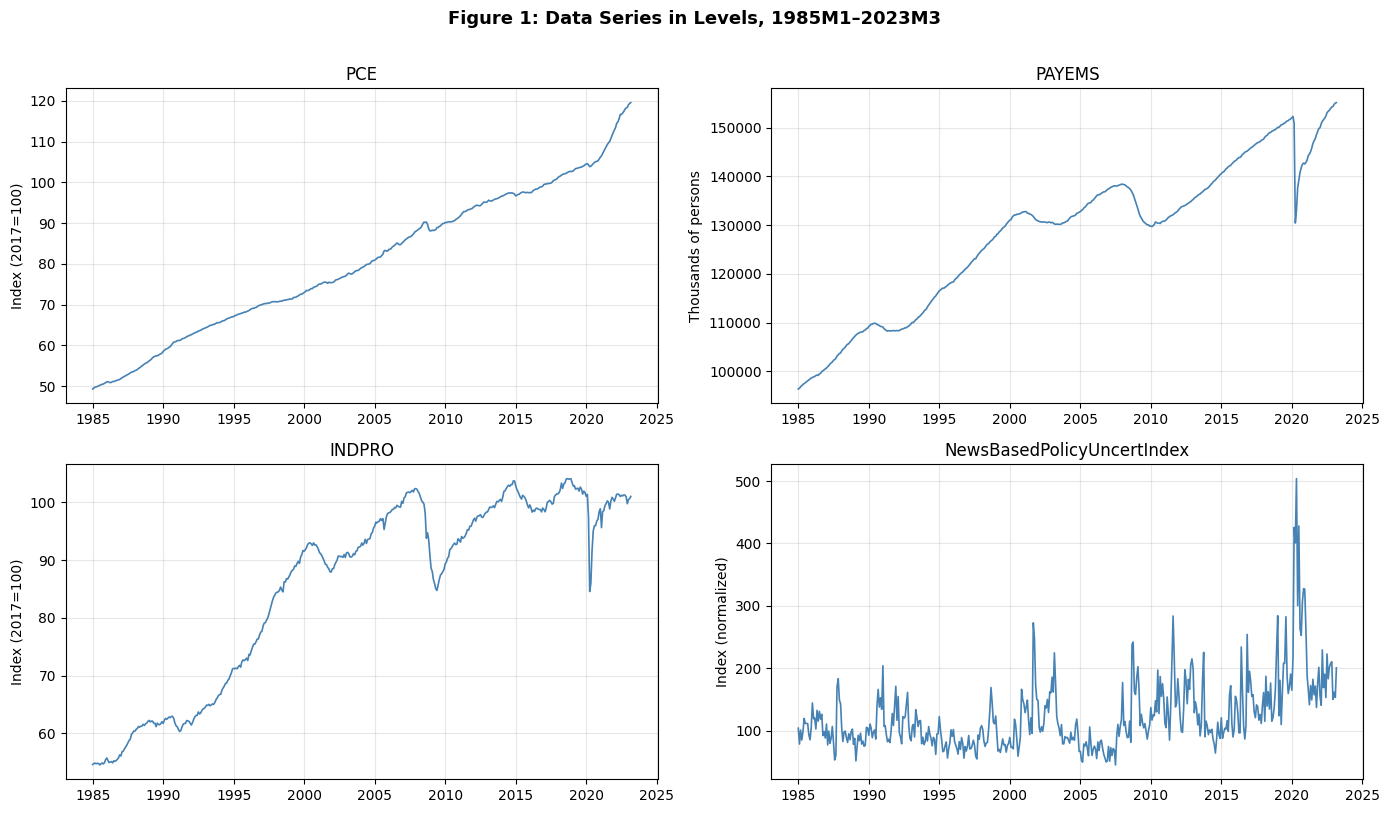

Figure saved to output/figure1_data_levels.pdf

Figure note: The four panels show the raw data series in levels,
seasonally adjusted, downloaded from FRED (PAYEMS, PCEPI, INDPRO)
and policyuncertainty.com (EPU). Sample: 1985M1-2023M3.


In [5]:
# Figure reproduction

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top-left: PCEPI
axes[0, 0].plot(
    data_levels.index,
    data_levels["PCEPI"],
    color="steelblue", linewidth=1.2
)
axes[0, 0].set_title("PCE", fontsize=12)
axes[0, 0].set_ylabel("Index (2017=100)")
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator(5))
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0, 0].grid(True, alpha=0.3)

# Top-right: PAYEMS
axes[0, 1].plot(
    data_levels.index,
    data_levels["PAYEMS"],
    color="steelblue", linewidth=1.2
)
axes[0, 1].set_title("PAYEMS", fontsize=12)
axes[0, 1].set_ylabel("Thousands of persons")
axes[0, 1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: INDPRO
axes[1, 0].plot(
    data_levels.index,
    data_levels["INDPRO"],
    color="steelblue", linewidth=1.2
)
axes[1, 0].set_title("INDPRO", fontsize=12)
axes[1, 0].set_ylabel("Index (2017=100)")
axes[1, 0].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: EPU
axes[1, 1].plot(
    data_levels.index,
    data_levels["EPU"],
    color="steelblue", linewidth=1.2
)
axes[1, 1].set_title("NewsBasedPolicyUncertIndex", fontsize=12)
axes[1, 1].set_ylabel("Index (normalized)")
axes[1, 1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1, 1].grid(True, alpha=0.3)

# Figure-level formatting
fig.suptitle(
    "Figure 1: Data Series in Levels, 1985M1–2023M3",
    fontsize=13, fontweight="bold", y=1.01
)
fig.tight_layout()

# Save to output folder
fig.savefig(
    "../output/figure1_data_levels.pdf",
    bbox_inches="tight", dpi=300
)

plt.show()
print("Figure saved to output/figure1_data_levels.pdf")
print("\nFigure note: The four panels show the raw data series in levels,")
print("seasonally adjusted, downloaded from FRED (PAYEMS, PCEPI, INDPRO)")
print("and policyuncertainty.com (EPU). Sample: 1985M1-2023M3.")

#### 2) VAR ESTIMATION

In [6]:
# Month-on-month growth rates for PAYEMS, INDPRO, PCEPI
data_growth = pd.DataFrame(index=data_levels.index)

data_growth["PAYEMS_g"] = data_levels["PAYEMS"].pct_change(1) * 100 # employment growth rate
data_growth["INDPRO_g"] = data_levels["INDPRO"].pct_change(1) * 100 # industrial production growth
data_growth["PCEPI_g"]  = data_levels["PCEPI"].pct_change(1)  * 100 # price inflation rate
data_growth["EPU"]      = data_levels["EPU"] # EPU stays in levels

data_growth = data_growth.dropna()

print(f"Transformed data shape: {data_growth.shape}")
print(f"Date range: {data_growth.index[0].date()} - {data_growth.index[-1].date()}")

# VAR input
# Ordering: EPU, PAYEMS, INDPRO, PCEPI
var_order = ["EPU", "PAYEMS_g", "INDPRO_g", "PCEPI_g"]

data_var = data_growth[var_order].copy()

print(f"\nVAR variable ordering (matters for identification):")
for i, v in enumerate(var_order, 1):
    print(f"  {i}. {v}")

# Split into estimation sample (1985M2–2019M12) and full sample
data_est = data_var.loc[:"2019-12-01"].copy()
data_full = data_var.copy()

print(f"\nEstimation sample: {data_est.index[0].date()} - {data_est.index[-1].date()}")
print(f"Estimation sample shape: {data_est.shape}")

# Summary statistics for the estimation sample
print(f"\nSummary statistics (estimation sample):")
print(data_est.describe().round(3))

Transformed data shape: (458, 4)
Date range: 1985-02-01 - 2023-03-01

VAR variable ordering (matters for identification):
  1. EPU
  2. PAYEMS_g
  3. INDPRO_g
  4. PCEPI_g

Estimation sample: 1985-02-01 - 2019-12-01
Estimation sample shape: (419, 4)

Summary statistics (estimation sample):
           EPU  PAYEMS_g  INDPRO_g  PCEPI_g
count  419.000   419.000   419.000  419.000
mean   113.775     0.109     0.150    0.179
std     42.869     0.156     0.605    0.187
min     44.783    -0.618    -4.405   -1.180
25%     84.390     0.047    -0.192    0.084
50%    103.700     0.135     0.206    0.179
75%    135.660     0.209     0.521    0.286
max    284.136     0.478     2.070    0.965


In [7]:
# Reduced-form VAR(1) estimation

model = VAR(data_est)
results = model.fit(maxlags=1, trend='c')

# Prints the tables and the correlation matric
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 15, Jun, 2026
Time:                     16:04:22
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -2.26995
Nobs:                     418.000    HQIC:                  -2.38671
Log likelihood:          -1837.69    FPE:                  0.0851762
AIC:                     -2.46304    Det(Omega_mle):       0.0812198
--------------------------------------------------------------------
Results for equation EPU
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              46.066569         5.345725            8.617           0.000
L1.EPU              0.640823         0.037973           16.876           0.000
L1.PAYEMS_g       -19.312979        11.393270           -1.695        

In [8]:
# Report the 4 VAR equations and Σ_u

params = results.params
var_names = data_est.columns.tolist()

# Print the 4 equations
print("=" * 70)
print("ANSWER TO Q2d: Estimated Reduced-Form VAR(1) Equations")
print("=" * 70)

eq_labels = ["EPU", "PAYEMS_g", "INDPRO_g", "PCEPI_g"]
lag_labels = ["EPU", "PAYEMS_g", "INDPRO_g", "PCEPI_g"]

for eq in eq_labels:
    const_val = params.loc["const", eq]
    print(f"\nEquation for {eq}:")
    print(f"  {eq}_t = {const_val:.6f}", end="")

    for lag_var in lag_labels:
        coef = params.loc[f"L1.{lag_var}", eq]
        sign = "+" if coef >= 0 else "-"
        print(f" {sign} {abs(coef):.6f}·{lag_var}_{{t-1}}", end="")

    print(f" + u_{eq}")

# Extract and display Σ_u
print("\n" + "=" * 70)
print("ANSWER TO Q2e: Variance-Covariance Matrix of Residuals (Σ_u)")
print("=" * 70)

sigma_u = results.sigma_u

sigma_df = pd.DataFrame(
    sigma_u,
    index=var_names,
    columns=var_names
)

print("\nΣ_u (variance-covariance matrix of reduced-form residuals):")
print(sigma_df.round(6).to_string())

# Also show the standard deviations
print("\nStandard deviations of residuals (√diagonal of Σ_u):")
diag_values = np.diag(sigma_u)

for i, v in enumerate(var_names):
    sd = np.sqrt(diag_values[i])
    print(f"  σ_{v:12s} = {sd:.6f}")

ANSWER TO Q2d: Estimated Reduced-Form VAR(1) Equations

Equation for EPU:
  EPU_t = 46.066569 + 0.640823·EPU_{t-1} - 19.312979·PAYEMS_g_{t-1} - 3.539922·INDPRO_g_{t-1} - 13.224534·PCEPI_g_{t-1} + u_EPU

Equation for PAYEMS_g:
  PAYEMS_g_t = 0.057868 - 0.000278·EPU_{t-1} + 0.679160·PAYEMS_g_{t-1} + 0.016831·INDPRO_g_{t-1} + 0.033143·PCEPI_g_{t-1} + u_PAYEMS_g

Equation for INDPRO_g:
  INDPRO_g_t = 0.110847 - 0.001359·EPU_{t-1} + 0.924909·PAYEMS_g_{t-1} + 0.073149·INDPRO_g_{t-1} + 0.458180·PCEPI_g_{t-1} + u_INDPRO_g

Equation for PCEPI_g:
  PCEPI_g_t = 0.168163 - 0.000578·EPU_{t-1} + 0.020911·PAYEMS_g_{t-1} + 0.009287·INDPRO_g_{t-1} + 0.403657·PCEPI_g_{t-1} + u_PCEPI_g

ANSWER TO Q2e: Variance-Covariance Matrix of Residuals (Σ_u)

Σ_u (variance-covariance matrix of reduced-form residuals):
                 EPU  PAYEMS_g  INDPRO_g   PCEPI_g
EPU       964.407146 -0.182425 -0.946386 -0.098089
PAYEMS_g   -0.182425  0.010779  0.018707  0.001362
INDPRO_g   -0.946386  0.018707  0.317218 -0.0022

In [9]:
# Cholesky decomposition structural impact matrix P

P = cholesky(sigma_u, lower=True)

print("Structural impact matrix P (lower-triangular Cholesky factor of Σ_u):")
P_df = pd.DataFrame(
    P,
    index=var_names,
    columns=[f"shock_{v}" for v in var_names]
)
print(P_df.round(6).to_string())

# Verify that P @ P.T = Σ_u
reconstruction = P @ P.T
max_error = np.max(np.abs(reconstruction - sigma_u))
print(f"\nVerification: max|P@P.T - Σ_u| = {max_error:.2e}")

# Normalize P by P[0,0] to get P̃ (impact per 1-unit EPU shock)
p11 = P[0, 0]
P_normalized_col1 = P[:, 0] / p11

print(f"\nP[0,0] = p11 = {p11:.6f}")
print(f"(A 1-unit EPU shock raises EPU by {p11:.4f} index points on impact)")

print("\nNormalized first column P̃_{·,1} (effect of +1 EPU index point shock):")
for i, v in enumerate(var_names):          # print each element with its label
    print(f"  {v:12s}: {P_normalized_col1[i]:.8f}")

# Store the four normalized impact coefficients for later use 
chol_11 = P_normalized_col1[0]
chol_21 = P_normalized_col1[1]
chol_31 = P_normalized_col1[2]
chol_41 = P_normalized_col1[3]

print(f"\nStored impact coefficients for structural forecast:")
print(f"  chol_11 (EPU→EPU)      = {chol_11:.8f}")
print(f"  chol_21 (EPU→PAYEMS_g) = {chol_21:.8f}")
print(f"  chol_31 (EPU→INDPRO_g) = {chol_31:.8f}")
print(f"  chol_41 (EPU→PCEPI_g)  = {chol_41:.8f}")

Structural impact matrix P (lower-triangular Cholesky factor of Σ_u):
          shock_EPU  shock_PAYEMS_g  shock_INDPRO_g  shock_PCEPI_g
EPU       31.054905        0.000000        0.000000       0.000000
PAYEMS_g  -0.005874        0.103655        0.000000       0.000000
INDPRO_g  -0.030475        0.178742        0.533235       0.000000
PCEPI_g   -0.003159        0.012964       -0.008801       0.166031

Verification: max|P@P.T - Σ_u| = 1.14e-13

P[0,0] = p11 = 31.054905
(A 1-unit EPU shock raises EPU by 31.0549 index points on impact)

Normalized first column P̃_{·,1} (effect of +1 EPU index point shock):
  EPU         : 1.00000000
  PAYEMS_g    : -0.00018916
  INDPRO_g    : -0.00098131
  PCEPI_g     : -0.00010171

Stored impact coefficients for structural forecast:
  chol_11 (EPU→EPU)      = 1.00000000
  chol_21 (EPU→PAYEMS_g) = -0.00018916
  chol_31 (EPU→INDPRO_g) = -0.00098131
  chol_41 (EPU→PCEPI_g)  = -0.00010171


#### 3) IMPULSE RESPONSE FUNCTIONS (IRFs)

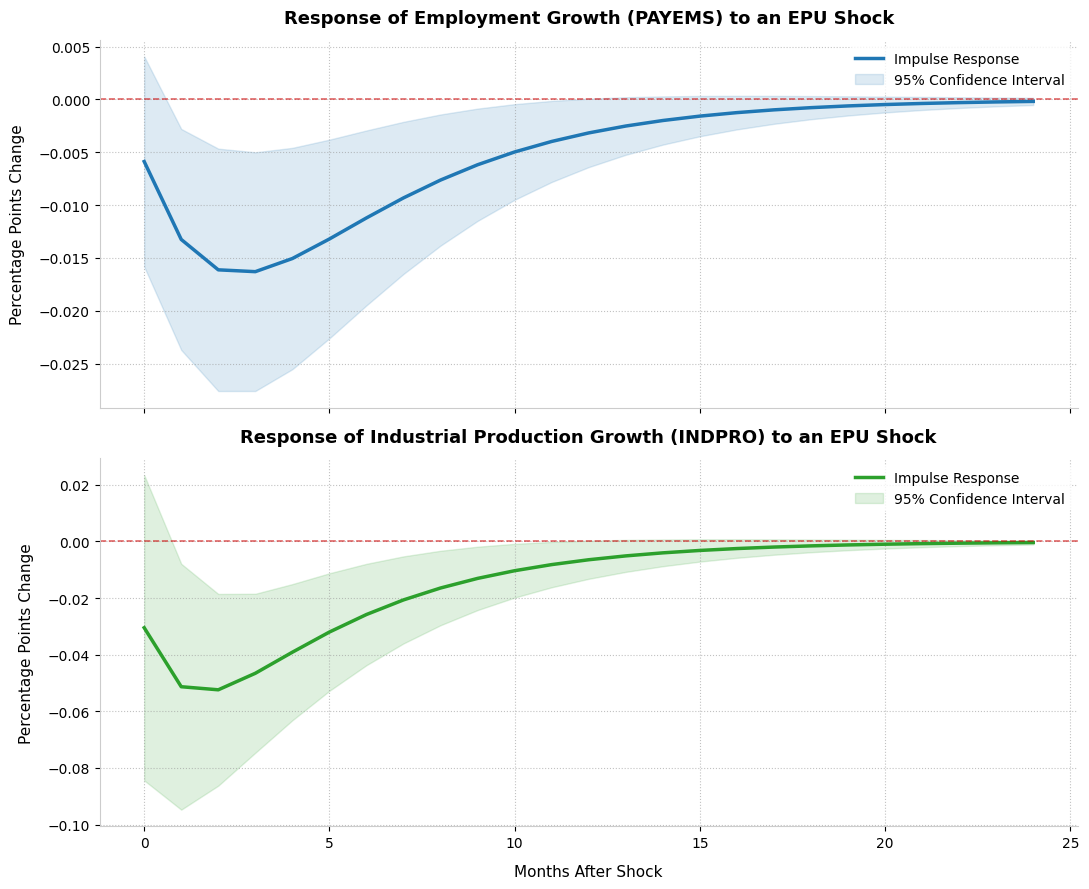

In [10]:
# Compute the Impulse Responses
irf = results.irf(periods=24)
steps = np.arange(25)

#print(results.names)
epu_idx = results.names.index('EPU')
payems_idx = results.names.index('PAYEMS_g')
indpro_idx = results.names.index('INDPRO_g')

# Extract exact values calculated by statsmodels
irf_payems = irf.orth_irfs[:, payems_idx, epu_idx]
irf_indpro = irf.orth_irfs[:, indpro_idx, epu_idx]

# Extract the orthogonalized standard errors
orth_errors = irf.stderr(orth=True)
se_payems = orth_errors[:, payems_idx, epu_idx]
se_indpro = orth_errors[:, indpro_idx, epu_idx]

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
ax1, ax2 = axes

colors = {'PAYEMS': '#1f77b4', 'INDPRO': '#2ca02c', 'baseline': '#cc0000'}

# Subplot 1: PAYEMS
ax1.plot(steps, irf_payems, color=colors['PAYEMS'], linewidth=2.5, label='Impulse Response')
ax1.fill_between(steps, 
                 irf_payems - 1.96 * se_payems, 
                 irf_payems + 1.96 * se_payems, 
                 color=colors['PAYEMS'], alpha=0.15, label='95% Confidence Interval')
ax1.set_title("Response of Employment Growth (PAYEMS) to an EPU Shock", fontsize=13, fontweight='bold', pad=12)

# Subplot 2: INDPRO
ax2.plot(steps, irf_indpro, color=colors['INDPRO'], linewidth=2.5, label='Impulse Response')
ax2.fill_between(steps, 
                 irf_indpro - 1.96 * se_indpro, 
                 irf_indpro + 1.96 * se_indpro, 
                 color=colors['INDPRO'], alpha=0.15, label='95% Confidence Interval')
ax2.set_title("Response of Industrial Production Growth (INDPRO) to an EPU Shock", fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel("Months After Shock", fontsize=11, labelpad=10)

for ax in [ax1, ax2]:
    ax.set_ylabel("Percentage Points Change", fontsize=11, labelpad=10)
    ax.axhline(0, color=colors['baseline'], linestyle='--', linewidth=1.2, alpha=0.6)
    ax.grid(True, linestyle=':', alpha=0.6, color='#999999')
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

## Part II
---

#### 1) UNCONDITIONAL FORECASTING

In [11]:
# Unconditional 12-step forecast from March 2023

# Extract VAR coefficients
phi = {}
for eq in var_order:
    phi[eq] = results.params[eq].values

T_date = "2023-03-01"
y_T = data_var.loc[T_date].values

print(f"Starting point (March 2023 observed values):")
for i, v in enumerate(var_order):
    print(f"  {v:12s} = {y_T[i]:.6f}")

# Unconditional forecast recursion
H = 12
forecast_dates = pd.date_range(
    start="2023-04-01", periods=H, freq="MS"
)

f_unco = np.zeros((H, 4))
y_prev = y_T.copy()

for h in range(H):
    y_next = np.zeros(4)
    for i, eq in enumerate(var_order):
        y_next[i] = (phi[eq][0]
                   + phi[eq][1] * y_prev[0]
                   + phi[eq][2] * y_prev[1]
                   + phi[eq][3] * y_prev[2]
                   + phi[eq][4] * y_prev[3])
    f_unco[h] = y_next
    y_prev = y_next

f_unco_df = pd.DataFrame(
    f_unco,
    index=forecast_dates,
    columns=var_order # ['EPU','PAYEMS_g','INDPRO_g','PCEPI_g']
)

# Print the forecast table
print(f"\nUnconditional forecast (Apr 2023 - Mar 2024):")
print(f"{'Date':>12} {'EPU':>10} {'PAYEMS_g':>12} {'INDPRO_g':>12} {'PCEPI_g':>10}")
print("-" * 60)
for date, row in f_unco_df.iterrows():
    print(f"{str(date.date()):>12} {row['EPU']:>10.4f} "
          f"{row['PAYEMS_g']:>12.6f} {row['INDPRO_g']:>12.6f} "
          f"{row['PCEPI_g']:>10.6f}")

Starting point (March 2023 observed values):
  EPU          = 200.489936
  PAYEMS_g     = 0.043852
  INDPRO_g     = 0.376484
  PCEPI_g      = 0.141578

Unconditional forecast (Apr 2023 - Mar 2024):
        Date        EPU     PAYEMS_g     INDPRO_g    PCEPI_g
------------------------------------------------------------
  2023-04-01   170.4933     0.042905    -0.028702   0.113859
  2023-05-01   153.0899     0.042868    -0.031144   0.116222
  2023-06-01   141.9155     0.047721    -0.006619   0.127211
  2023-07-01   134.4289     0.054903     0.019888   0.138433
  2023-08-01   129.2503     0.062682     0.043788   0.147686
  2023-09-01   125.5745     0.070114     0.064009   0.154799
  2023-10-01   122.9098     0.076761     0.080617   0.160137
  2023-11-01   120.9445     0.082472     0.094047   0.164126
  2023-12-01   119.4744     0.087257     0.104811   0.167115
  2024-01-01   118.3624     0.091195     0.113392   0.169372
  2024-02-01   117.5134     0.094398     0.120207   0.171087
  2024-03

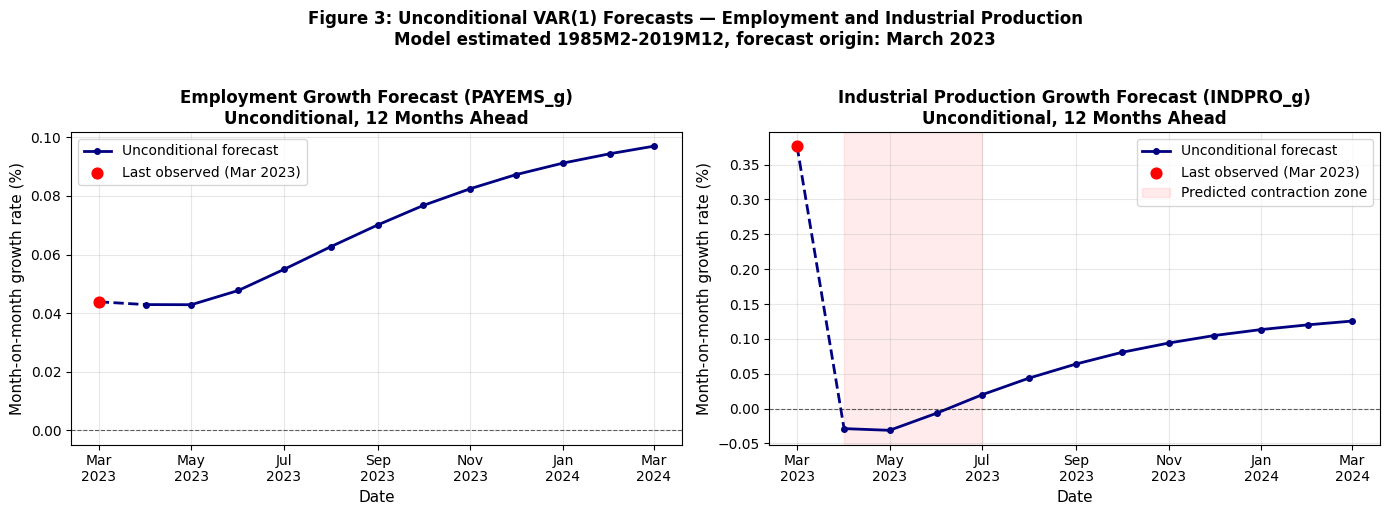

Figure 3 saved to output/figure3_unconditional_forecast.pdf


In [12]:
# Plot unconditional forecast for PAYEMS_g and INDPRO_g

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

anchor_date = pd.Timestamp("2023-03-01")
anchor_pay = data_var.loc["2023-03-01", "PAYEMS_g"]
anchor_ind = data_var.loc["2023-03-01", "INDPRO_g"]

plot_dates = [anchor_date] + list(f_unco_df.index)
plot_pay = [anchor_pay] + list(f_unco_df["PAYEMS_g"])
plot_ind = [anchor_ind] + list(f_unco_df["INDPRO_g"])

# Panel 1: PAYEMS growth forecast
axes[0].plot(
    plot_dates[1:], plot_pay[1:],
    color="navy", linewidth=2.0, marker="o",
    markersize=4, label="Unconditional forecast"
)
axes[0].plot(
    [plot_dates[0], plot_dates[1]],
    [plot_pay[0], plot_pay[1]],
    color="navy", linewidth=2.0, linestyle="--"
)
axes[0].scatter(
    [anchor_date], [anchor_pay],
    color="red", zorder=5, s=60, label="Last observed (Mar 2023)"
)
axes[0].axhline(0, color="black",
    linewidth=0.8, linestyle="--", alpha=0.6)
axes[0].set_title(
    "Employment Growth Forecast (PAYEMS_g)\nUnconditional, 12 Months Ahead",
    fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Date", fontsize=11)
axes[0].set_ylabel("Month-on-month growth rate (%)", fontsize=11)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel 2: INDPRO growth forecast
axes[1].plot(
    plot_dates[1:], plot_ind[1:],
    color="navy", linewidth=2.0, marker="o",
    markersize=4, label="Unconditional forecast"
)
axes[1].plot(
    [plot_dates[0], plot_dates[1]],
    [plot_ind[0], plot_ind[1]],
    color="navy", linewidth=2.0, linestyle="--"
)
axes[1].scatter(
    [anchor_date], [anchor_ind],
    color="red", zorder=5, s=60, label="Last observed (Mar 2023)"
)
axes[1].axhline(0, color="black",
    linewidth=0.8, linestyle="--", alpha=0.6)
axes[1].axvspan(
    plot_dates[1], pd.Timestamp("2023-07-01"),
    alpha=0.08, color="red", label="Predicted contraction zone"
)
axes[1].set_title(
    "Industrial Production Growth Forecast (INDPRO_g)\nUnconditional, 12 Months Ahead",
    fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Date", fontsize=11)
axes[1].set_ylabel("Month-on-month growth rate (%)", fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)


# Formatting
fig.suptitle(
    "Figure 3: Unconditional VAR(1) Forecasts — Employment and Industrial Production\n"
    "Model estimated 1985M2-2019M12, forecast origin: March 2023",
    fontsize=12, fontweight="bold", y=1.02
)
fig.tight_layout()

fig.savefig(
    "../output/figure3_unconditional_forecast.pdf",
    bbox_inches="tight", dpi=300
)
plt.show()
print("Figure 3 saved to output/figure3_unconditional_forecast.pdf")

#### 2) STRUCTURAL CONDITIONAL FORECASTING

In [13]:
# Build the EPU election scenario path

election_dates = [
    "2020-10-01",
    "2020-11-01",
    "2020-12-01",
    "2021-01-01",
    "2021-02-01",
]
scenario_months = [
    "2023-04-01", # receives Oct 2020 EPU value
    "2023-05-01", # receives Nov 2020 EPU value
    "2023-06-01", # receives Dec 2020 EPU value
    "2023-07-01", # receives Jan 2021 EPU value
    "2023-08-01", # receives Feb 2021 EPU value
]

epu_election = data_levels.loc[election_dates, "EPU"].values

print("EPU scenario path (2020 election values - assigned to 2023):")
print(f"{'2023 Month':>12}  {'Source Date':>12}  {'EPU Value':>10}")
print("-" * 40)
for i, (src, tgt) in enumerate(zip(election_dates, scenario_months)):
    print(f"{tgt:>12}  {src:>12}  {epu_election[i]:>10.4f}")

# Compare scenario EPU to unconditional EPU forecast
# The unconditional forecast of EPU for Apr–Aug 2023
epu_unco_scenario = f_unco_df.loc[scenario_months, "EPU"].values

print(f"\nComparison: scenario EPU vs unconditional EPU forecast")
print(f"{'Month':>12}  {'Scenario':>10}  {'Free VAR':>10}  {'Gap (ΔEPU)':>12}")
print("-" * 50)
for i, month in enumerate(scenario_months):
    gap = epu_election[i] - epu_unco_scenario[i]
    print(f"{month:>12}  {epu_election[i]:>10.4f}  "
          f"{epu_unco_scenario[i]:>10.4f}  {gap:>+12.4f}")

EPU scenario path (2020 election values - assigned to 2023):
  2023 Month   Source Date   EPU Value
----------------------------------------
  2023-04-01    2020-10-01    305.7666
  2023-05-01    2020-11-01    327.6096
  2023-06-01    2020-12-01    326.6166
  2023-07-01    2021-01-01    261.3061
  2023-08-01    2021-02-01    187.5196

Comparison: scenario EPU vs unconditional EPU forecast
       Month    Scenario    Free VAR    Gap (ΔEPU)
--------------------------------------------------
  2023-04-01    305.7666    170.4933     +135.2733
  2023-05-01    327.6096    153.0899     +174.5197
  2023-06-01    326.6166    141.9155     +184.7011
  2023-07-01    261.3061    134.4289     +126.8773
  2023-08-01    187.5196    129.2503      +58.2693


In [14]:
# Structural conditional forecast

# Build the full 12-month EPU scenario array
epu_scenario_full = np.full(H, np.nan)
for i, month in enumerate(scenario_months):
    h_idx = list(f_unco_df.index).index(pd.Timestamp(month))
    epu_scenario_full[h_idx] = epu_election[i]

print("EPU scenario array (NaN = free evolution after Aug 2023):")
for h in range(H):
    val = f"{epu_scenario_full[h]:.4f}" if not np.isnan(epu_scenario_full[h]) else "free"
    print(f"  h={h+1:>2} ({forecast_dates[h].strftime('%b %Y')}): {val}")

# Run the structural conditional forecast
P_tilde = np.array([chol_11, chol_21, chol_31, chol_41])

f_struct = np.zeros((H, 4))
y_prev_struct = y_T.copy()

for h in range(H):

    y_RF = np.zeros(4)
    for i, eq in enumerate(var_order):
        y_RF[i] = (phi[eq][0]
                 + phi[eq][1] * y_prev_struct[0]
                 + phi[eq][2] * y_prev_struct[1]
                 + phi[eq][3] * y_prev_struct[2]
                 + phi[eq][4] * y_prev_struct[3])

    if not np.isnan(epu_scenario_full[h]): # scenario month: impose EPU path
        delta_epu = epu_scenario_full[h] - y_RF[0] # gap = scenario - benchmark EPU
    else:
        delta_epu = 0.0

    y_struct = y_RF + P_tilde * delta_epu

    f_struct[h] = y_struct
    y_prev_struct = y_struct

f_struct_df = pd.DataFrame(
    f_struct,
    index=forecast_dates,
    columns=var_order
)

# Print comparison: unconditional vs structural
print(f"\n{'Date':>12} {'PAYEMS_g unco':>14} {'PAYEMS_g struct':>16} "
      f"{'IND_g unco':>12} {'IND_g struct':>13}")
print("-" * 72)
for date in forecast_dates:
    u_pay = f_unco_df.loc[date, "PAYEMS_g"]
    s_pay = f_struct_df.loc[date, "PAYEMS_g"]
    u_ind = f_unco_df.loc[date, "INDPRO_g"]
    s_ind = f_struct_df.loc[date, "INDPRO_g"]
    marker = " ←imposed" if date <= pd.Timestamp("2023-08-01") else ""
    print(f"{str(date.date()):>12} {u_pay:>14.6f} {s_pay:>16.6f} "
          f"{u_ind:>12.6f} {s_ind:>13.6f}{marker}")

EPU scenario array (NaN = free evolution after Aug 2023):
  h= 1 (Apr 2023): 305.7666
  h= 2 (May 2023): 327.6096
  h= 3 (Jun 2023): 326.6166
  h= 4 (Jul 2023): 261.3061
  h= 5 (Aug 2023): 187.5196
  h= 6 (Sep 2023): free
  h= 7 (Oct 2023): free
  h= 8 (Nov 2023): free
  h= 9 (Dec 2023): free
  h=10 (Jan 2024): free
  h=11 (Feb 2024): free
  h=12 (Mar 2024): free

        Date  PAYEMS_g unco  PAYEMS_g struct   IND_g unco  IND_g struct
------------------------------------------------------------------------
  2023-04-01       0.042905         0.017317    -0.028702     -0.161448 ←imposed
  2023-05-01       0.042868        -0.031230    -0.031144     -0.339763 ←imposed
  2023-06-01       0.047721        -0.072543    -0.006619     -0.445960 ←imposed
  2023-07-01       0.054903        -0.091037     0.019888     -0.446035 ←imposed
  2023-08-01       0.062682        -0.079711     0.043788     -0.348344 ←imposed
  2023-09-01       0.070114        -0.054309     0.064009     -0.243403
  2023-10-0

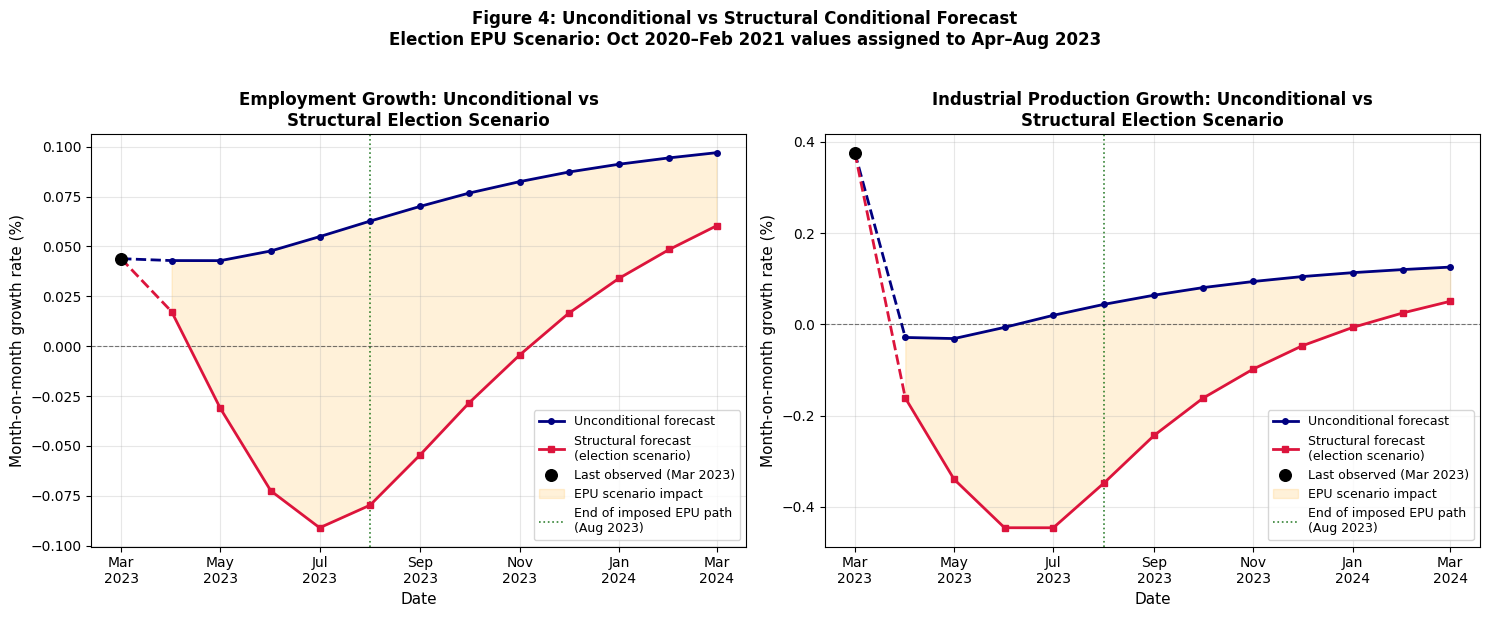

Figure 4 saved to output/figure4_structural_vs_unconditional.pdf


In [15]:
# Plot structural vs unconditional forecasts

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

imposed_end = pd.Timestamp("2023-08-01")

def plot_comparison_panel(ax, dates, unco, struct, anchor_val,
                           anchor_date, title, ylabel):
    """Plot unconditional vs structural forecast with shaded gap."""

    # plot dates as list for fill_between
    all_dates  = [anchor_date] + list(dates)
    all_unco   = [anchor_val]  + list(unco)
    all_struct = [anchor_val]  + list(struct)

    # unconditional forecast line
    ax.plot(all_dates[1:], all_unco[1:],
            color="navy", linewidth=2.0, marker="o",
            markersize=4, label="Unconditional forecast", zorder=3)

    # structural forecast line
    ax.plot(all_dates[1:], all_struct[1:],
            color="crimson", linewidth=2.0, marker="s",
            markersize=4, linestyle="-", label="Structural forecast\n(election scenario)",
            zorder=3)

    # connector lines from anchor
    ax.plot([all_dates[0], all_dates[1]], [all_unco[0],   all_unco[1]],
            color="navy",   linewidth=2.0, linestyle="--")
    ax.plot([all_dates[0], all_dates[1]], [all_struct[0], all_struct[1]],
            color="crimson", linewidth=2.0, linestyle="--")

    # anchor point
    ax.scatter([anchor_date], [anchor_val], color="black",
               zorder=5, s=70, label="Last observed (Mar 2023)")

    # shaded gap between the two forecasts
    ax.fill_between(list(dates), list(unco), list(struct),
                    alpha=0.15, color="orange",
                    label="EPU scenario impact")

    # vertical line marking end of imposed EPU path
    ax.axvline(imposed_end, color="darkgreen", linewidth=1.2,
               linestyle=":", alpha=0.8, label="End of imposed EPU path\n(Aug 2023)")

    # zero reference line
    ax.axhline(0, color="black", linewidth=0.8,
               linestyle="--", alpha=0.5)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, alpha=0.3)

# Panel 1: PAYEMS_g
plot_comparison_panel(
    axes[0],
    dates      = f_unco_df.index,
    unco       = f_unco_df["PAYEMS_g"].values,
    struct     = f_struct_df["PAYEMS_g"].values,
    anchor_val = data_var.loc["2023-03-01", "PAYEMS_g"],
    anchor_date= pd.Timestamp("2023-03-01"),
    title      = "Employment Growth: Unconditional vs\nStructural Election Scenario",
    ylabel     = "Month-on-month growth rate (%)"
)

# Panel 2: INDPRO_g
plot_comparison_panel(
    axes[1],
    dates      = f_unco_df.index,
    unco       = f_unco_df["INDPRO_g"].values,
    struct     = f_struct_df["INDPRO_g"].values,
    anchor_val = data_var.loc["2023-03-01", "INDPRO_g"],
    anchor_date= pd.Timestamp("2023-03-01"),
    title      = "Industrial Production Growth: Unconditional vs\nStructural Election Scenario",
    ylabel     = "Month-on-month growth rate (%)"
)

fig.suptitle(
    "Figure 4: Unconditional vs Structural Conditional Forecast\n"
    "Election EPU Scenario: Oct 2020–Feb 2021 values assigned to Apr–Aug 2023",
    fontsize=12, fontweight="bold", y=1.02
)
fig.tight_layout()

fig.savefig("../output/figure4_structural_vs_unconditional.pdf",
            bbox_inches="tight", dpi=300)
plt.show()
print("Figure 4 saved to output/figure4_structural_vs_unconditional.pdf")